<a href="https://colab.research.google.com/github/KhushnurAnjum26/machine-Learning/blob/main/k_medoids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Required Libraries

In [1]:
!pip uninstall -y numpy
!pip install numpy==1.26.4


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.36.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 

In [1]:
!pip install scikit-learn-extra==0.3.0



Import Required Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [3]:
df = pd.read_csv("Mall_Customers.csv")


In [4]:
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape


(200, 5)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.isnull().sum()


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [9]:
df = df.dropna()


In [10]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
df_numeric.head()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


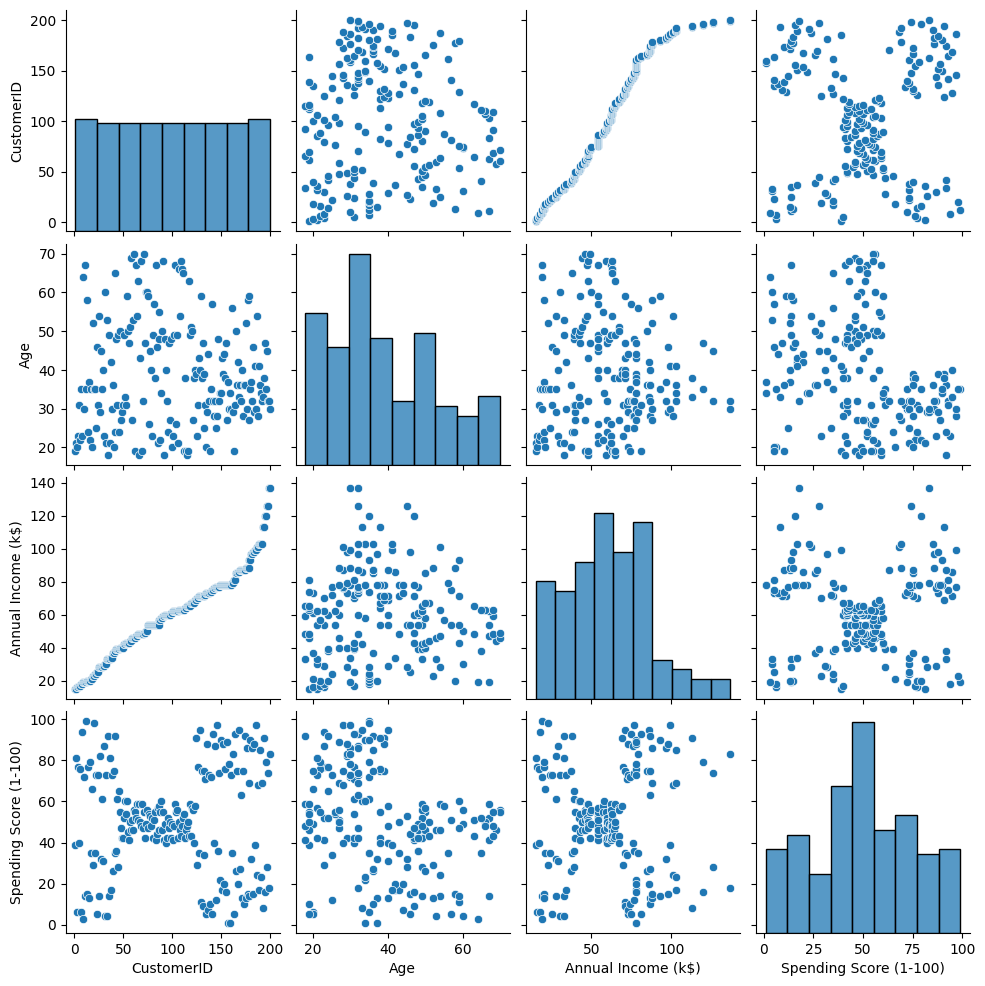

In [11]:
sns.pairplot(df_numeric)
plt.show()


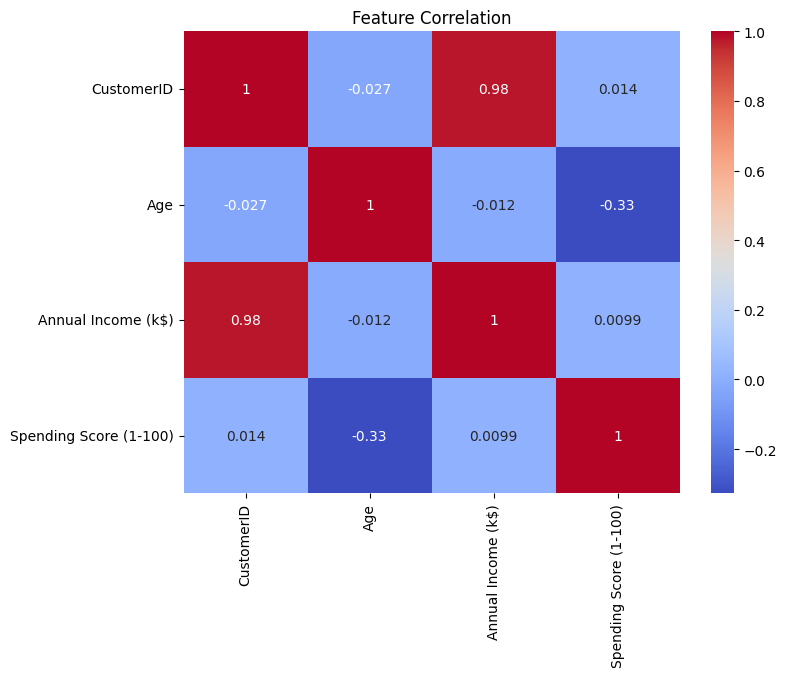

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


In [13]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)


In [14]:
costs = []

for k in range(2, 11):
    kmedoids = KMedoids(n_clusters=k, metric='euclidean', random_state=42)
    kmedoids.fit(scaled_data)
    costs.append(kmedoids.inertia_)


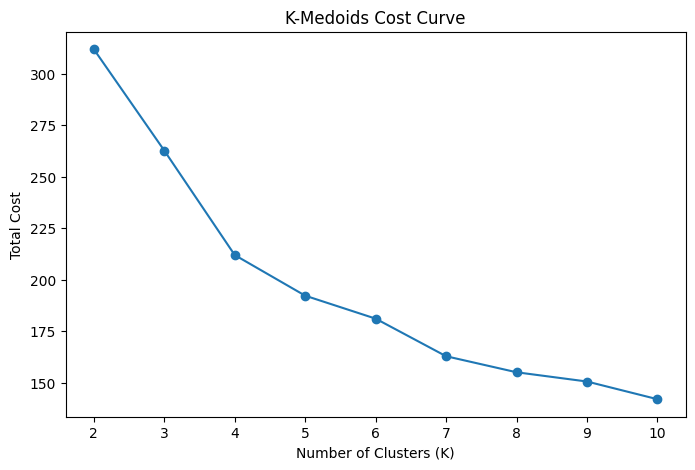

In [15]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), costs, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Total Cost")
plt.title("K-Medoids Cost Curve")
plt.show()


In [16]:
kmedoids = KMedoids(
    n_clusters=3,
    metric='euclidean',
    random_state=42
)


In [17]:
kmedoids.fit(scaled_data)


KMedoids(n_clusters=3, random_state=42)

In [18]:
clusters = kmedoids.predict(scaled_data)


In [19]:
df['Cluster'] = clusters
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


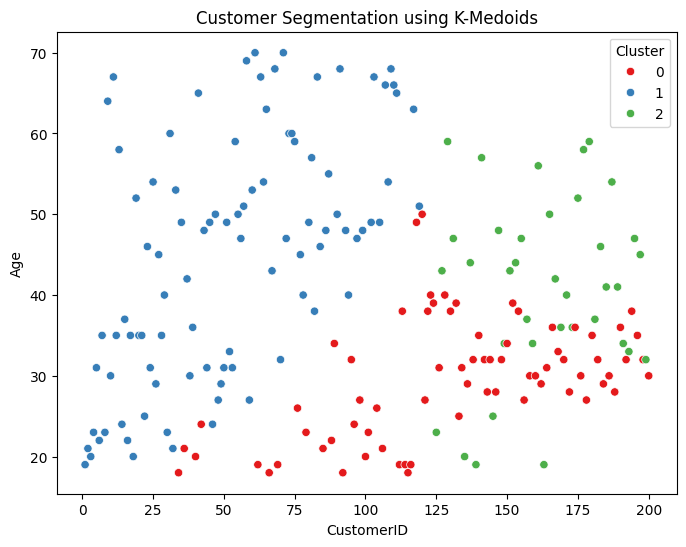

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_numeric.iloc[:,0],
    y=df_numeric.iloc[:,1],
    hue=df['Cluster'],
    palette='Set1'
)
plt.title("Customer Segmentation using K-Medoids")
plt.show()


In [21]:
sil_score = silhouette_score(scaled_data, clusters)
sil_score


0.32466430268448443

In [25]:
df.groupby('Cluster').mean(numeric_only=True)



,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,131.352113,29.591549,73.591549,69.718310
1,52.623656,45.021505,40.096774,47.913978
2,163.333333,41.166667,87.722222,17.611111


In [26]:
medoid_indices = kmedoids.medoid_indices_
medoid_indices


array([133,  55, 166])

In [27]:
df.to_csv("kmedoids_clustered_customers.csv", index=False)
